In [ ]:
"""The script reads a weight-height dataset, removes outliers using Z-scores, transforms units, reduces skewness, and visualizes distributions before and after cleaning."""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("weight-height.csv")

In [3]:
print("First 5 rows of dataset:")
df.head()

First 5 rows of dataset:


,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [4]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           25000 non-null  int64  
 1   Height(Inches)  25000 non-null  float64
 2   Weight(Pounds)  25000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 586.1 KB
None


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Index             0
Height(Inches)    0
Weight(Pounds)    0
dtype: int64


In [6]:
print("\nNumber of Duplicated Rows:", df.duplicated().sum())


Number of Duplicated Rows: 0


In [7]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
              Index  Height(Inches)  Weight(Pounds)
count  25000.000000    25000.000000    25000.000000
mean   12500.500000       67.993114      127.079421
std     7217.022701        1.901679       11.660898
min        1.000000       60.278360       78.014760
25%     6250.750000       66.704397      119.308675
50%    12500.500000       67.995700      127.157750
75%    18750.250000       69.272958      134.892850
max    25000.000000       75.152800      170.924000


In [8]:
z_scores = np.abs(stats.zscore(df[['Height(Inches)', 'Weight(Pounds)']]))
outliers = (z_scores > 3)
print("\nNumber of Outliers (Z-score > 3):")
print(outliers.sum())


Number of Outliers (Z-score > 3):
120


In [9]:
df_clean = df[(z_scores < 3).all(axis=1)]
print("\nShape after removing outliers:", df_clean.shape)


Shape after removing outliers: (24886, 3)


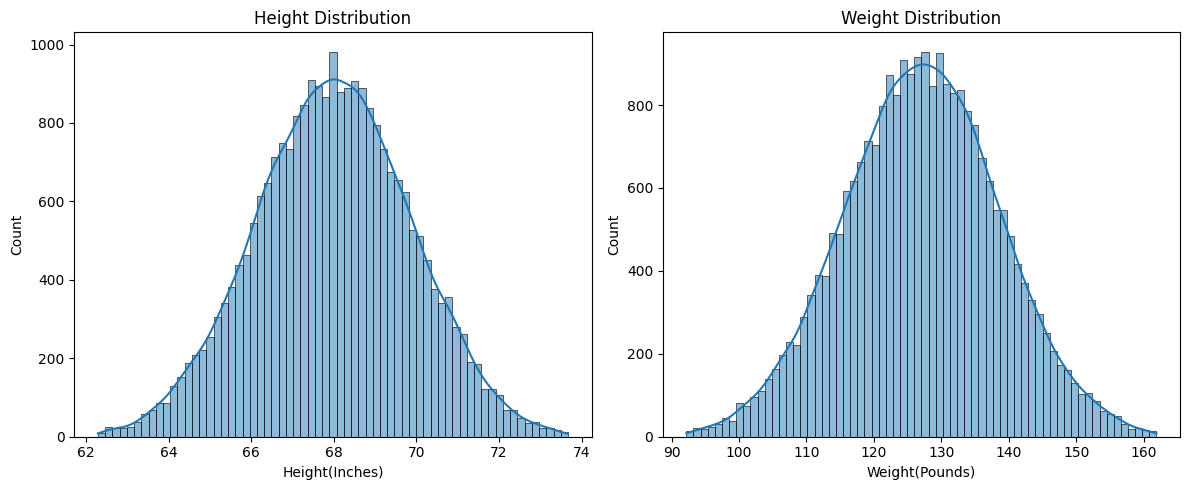

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['Height(Inches)'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['Weight(Pounds)'], kde=True)
plt.title('Weight Distribution')

plt.tight_layout()
plt.show()


In [16]:
df['height_zscore'] = np.abs(stats.zscore(df['Height(Inches)']))
df['weight_zscore'] = np.abs(stats.zscore(df['Weight(Pounds)']))

In [18]:
height_outliers = df[df['height_zscore'] > 3]
weight_outliers = df[df['weight_zscore'] > 3]

In [19]:
print("\n=== Height Outliers ===")
print(height_outliers[['Height(Inches)', 'height_zscore']])
print("\n=== Weight Outliers ===")
print(weight_outliers[['Weight(Pounds)', 'weight_zscore']])


=== Height Outliers ===
       Height(Inches)  height_zscore
138          73.90107       3.106768
174          73.83364       3.071309
412          62.01666       3.142788
1162         74.24899       3.289726
1383         74.19488       3.261271
1893         75.15280       3.765005
2395         73.99549       3.156420
2481         75.11519       3.745227
2651         60.61265       3.881103
3696         61.89340       3.207606
4191         74.03777       3.178653
4508         74.28376       3.308010
5641         60.86340       3.749243
6405         62.23548       3.027719
6481         61.59011       3.367094
6627         73.72628       3.014853
6941         61.40550       3.464174
7269         73.81695       3.062532
7839         73.85521       3.082652
8472         73.95409       3.134649
8828         74.27270       3.302194
9225         73.75335       3.029088
9492         74.05895       3.189791
9876         61.30021       3.519542
10240        61.93152       3.187560
10330        

In [20]:
print("\nOriginal shape:", df.shape)
df_clean = df[(df['height_zscore'] <= 3) & (df['weight_zscore'] <= 3)]
print("After removing outliers:", df_clean.shape)


Original shape: (25000, 5)
After removing outliers: (24886, 5)


In [21]:
df_clean['Height(cm)'] = df_clean['Height(Inches)'] * 2.54
df_clean['Weight(kg)'] = df_clean['Weight(Pounds)'] * 0.453592

C:\Users\singh\AppData\Local\Temp\ipykernel_17560\1408812459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Height(cm)'] = df_clean['Height(Inches)'] * 2.54
C:\Users\singh\AppData\Local\Temp\ipykernel_17560\1408812459.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Weight(kg)'] = df_clean['Weight(Pounds)'] * 0.453592


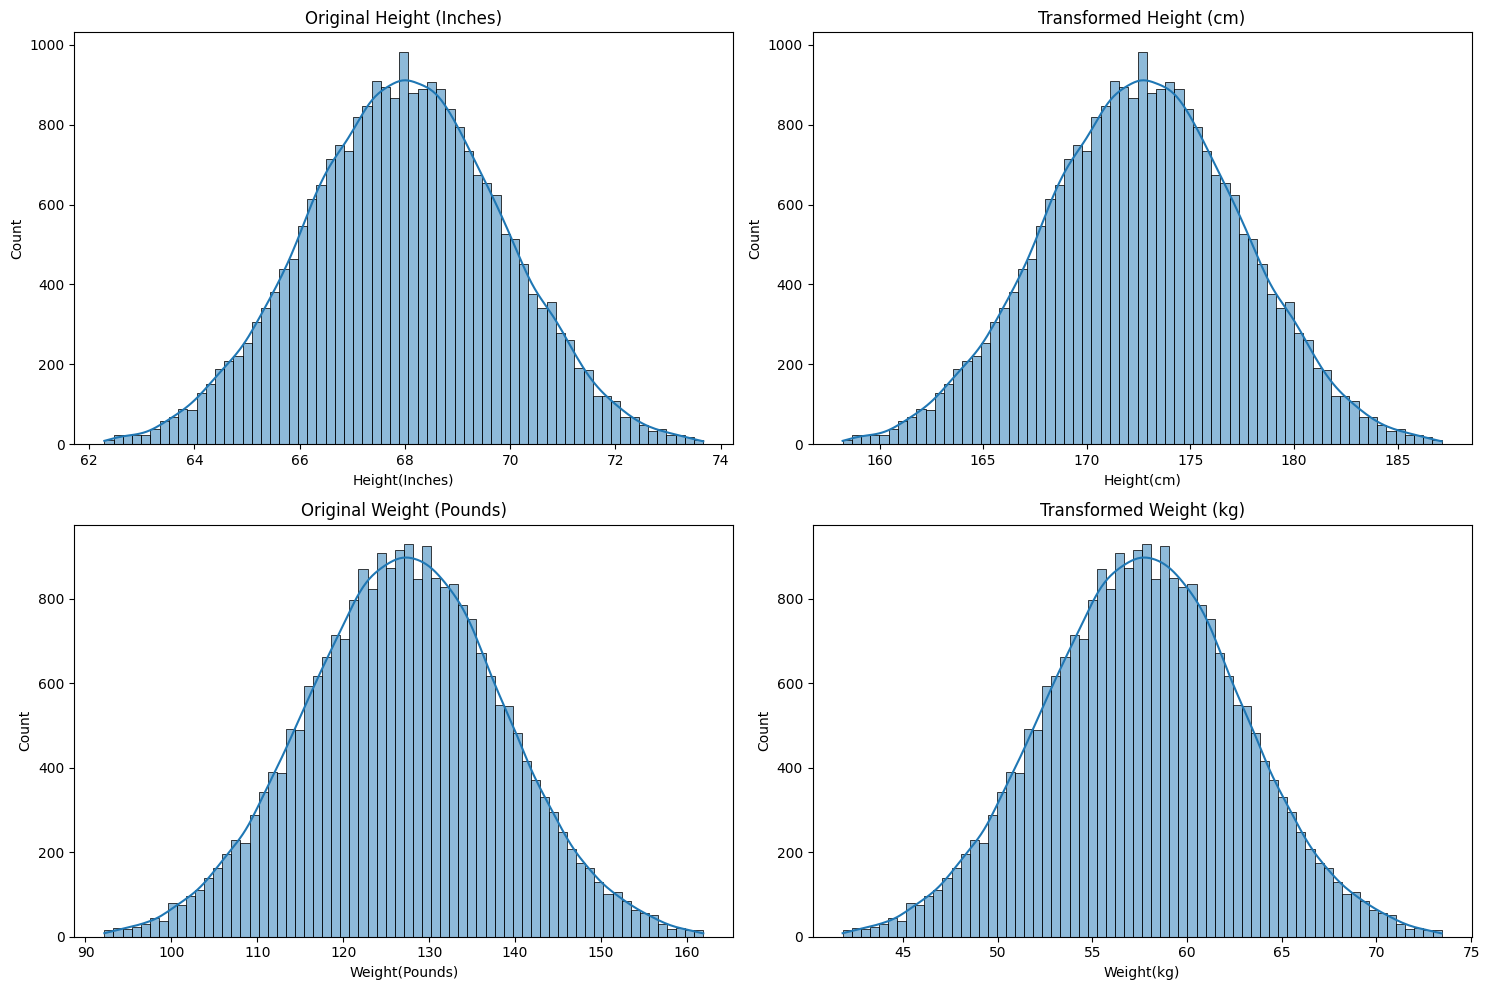

In [22]:
plt.figure(figsize=(15, 10))

# Original height distribution
plt.subplot(2, 2, 1)
sns.histplot(df_clean['Height(Inches)'], kde=True)
plt.title('Original Height (Inches)')

# Transformed height distribution
plt.subplot(2, 2, 2)
sns.histplot(df_clean['Height(cm)'], kde=True)
plt.title('Transformed Height (cm)')

# Original weight distribution
plt.subplot(2, 2, 3)
sns.histplot(df_clean['Weight(Pounds)'], kde=True)
plt.title('Original Weight (Pounds)')

# Transformed weight distribution
plt.subplot(2, 2, 4)
sns.histplot(df_clean['Weight(kg)'], kde=True)
plt.title('Transformed Weight (kg)')
plt.tight_layout()
plt.show()

In [23]:
print("\n=== Skewness Before Transformation ===")
print("Height skewness:", df_clean['Height(cm)'].skew())
print("Weight skewness:", df_clean['Weight(kg)'].skew())


=== Skewness Before Transformation ===
Height skewness: -0.016357087234219424
Weight skewness: -0.010608398719528775


In [24]:
df_clean['Weight_log'] = np.log(df_clean['Weight(kg)'])

C:\Users\singh\AppData\Local\Temp\ipykernel_17560\3300768496.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Weight_log'] = np.log(df_clean['Weight(kg)'])


In [25]:
print("\n=== Skewness After Log Transformation ===")
print("Weight log skewness:", df_clean['Weight_log'].skew())


=== Skewness After Log Transformation ===
Weight log skewness: -0.2688801363896045


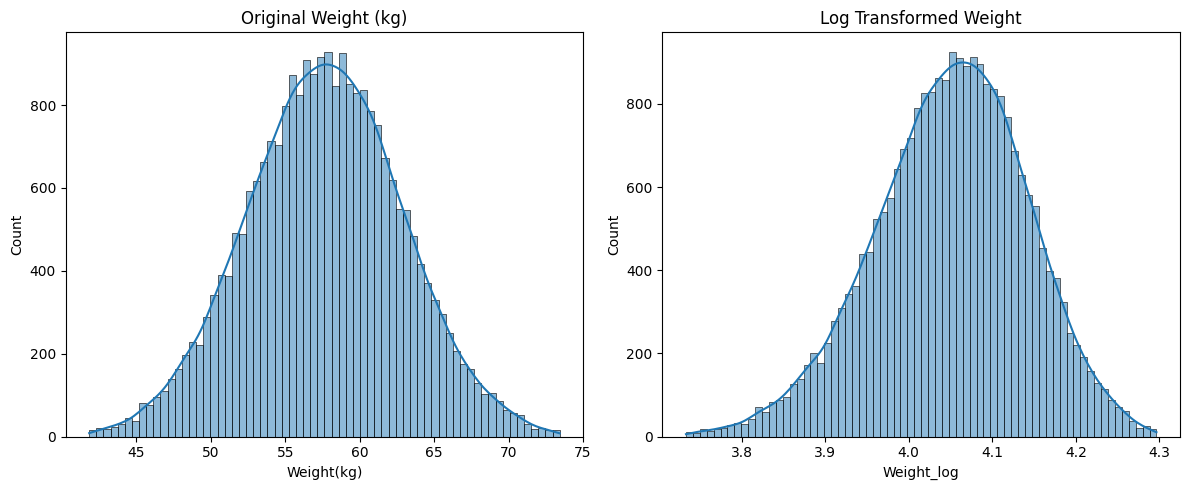

In [26]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Weight(kg)'], kde=True)
plt.title('Original Weight (kg)')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['Weight_log'], kde=True)
plt.title('Log Transformed Weight')
plt.tight_layout()
plt.show()


In [28]:
print("\n=== Final Cleaned Dataset ===")
df_clean.head()


=== Final Cleaned Dataset ===


,Index,Height(Inches),Weight(Pounds),height_zscore,weight_zscore,Height(cm),Weight(kg),Weight_log
0,1,65.78331,112.9925,1.162051,1.208072,167.089607,51.252494,3.936764
1,2,71.51521,136.4873,1.852136,0.806805,181.648633,61.909547,4.125674
2,3,69.39874,153.0269,0.739165,2.225214,176.272800,69.411778,4.240057
3,4,68.21660,142.3354,0.117523,1.308328,173.270164,64.562199,4.167629
4,5,67.78781,144.2971,0.107961,1.476561,172.181037,65.452010,4.181317


In [ ]:
"""1. Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
Loads essential libraries for data analysis and plotting.

scipy.stats is used for Z-score-based outlier detection.

📂 2. Reading Dataset

df = pd.read_csv("weight-height.csv")
Reads the CSV file into a DataFrame named df.

🧾 3. Initial Dataset Inspection

print("First 5 rows of dataset:")
df.head()
Shows the first five rows to preview data structure.


print("\nDataset Info:")
print(df.info())
Displays data types and non-null counts.


print("\nMissing Values:")
print(df.isnull().sum())
Counts any missing values in the dataset.


print("\nNumber of Duplicated Rows:", df.duplicated().sum())
Checks for duplicate rows.


print("\nSummary Statistics:")
print(df.describe())
Provides basic stats like mean, std, min, max, etc.

⚠️ 4. Outlier Detection Using Z-Score

z_scores = np.abs(stats.zscore(df[['Height(Inches)', 'Weight(Pounds)']]))
outliers = (z_scores > 3)
print("\nNumber of Outliers (Z-score > 3):")
print(outliers.sum())
Computes absolute Z-scores for Height and Weight.

Flags data points with Z-score > 3 as outliers.

Prints how many outliers were detected.

🧹 5. Removing Outliers

df_clean = df[(z_scores < 3).all(axis=1)]
print("\nShape after removing outliers:", df_clean.shape)
Filters out rows where any feature exceeds Z-score threshold.

Displays the new dataset shape after removal.

📊 6. Plot Height and Weight Distributions

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Height(Inches)'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['Weight(Pounds)'], kde=True)
plt.title('Weight Distribution')
plt.tight_layout()
plt.show()
Plots distribution of cleaned height and weight data.

Includes KDE curves to show density.

🔍 7. Z-Score Columns for Individual Features

df['height_zscore'] = np.abs(stats.zscore(df['Height(Inches)']))
df['weight_zscore'] = np.abs(stats.zscore(df['Weight(Pounds)']))
Adds Z-score columns for height and weight.

⚠️ 8. Separate Height and Weight Outliers

height_outliers = df[df['height_zscore'] > 3]
weight_outliers = df[df['weight_zscore'] > 3]
Isolates rows with height and weight outliers individually.


print("\n=== Height Outliers ===")
print(height_outliers[['Height(Inches)', 'height_zscore']])
Displays outlier values for height.


print("\n=== Weight Outliers ===")
print(weight_outliers[['Weight(Pounds)', 'weight_zscore']])
Displays outlier values for weight.

🧽 9. Drop Outliers Again (Final Clean)

print("\nOriginal shape:", df.shape)
df_clean = df[(df['height_zscore'] <= 3) & (df['weight_zscore'] <= 3)]
print("After removing outliers:", df_clean.shape)
Removes all rows having height or weight Z-score > 3 again.

Shows shape after final cleaning.

📏 10. Unit Conversion: Inches ➝ cm, Pounds ➝ kg

df_clean['Height(cm)'] = df_clean['Height(Inches)'] * 2.54
df_clean['Weight(kg)'] = df_clean['Weight(Pounds)'] * 0.453592
Adds new columns converting units to metric system.

📉 11. Compare Original vs Transformed Distributions

plt.figure(figsize=(15, 10))
# Original height distribution
plt.subplot(2, 2, 1)
sns.histplot(df_clean['Height(Inches)'], kde=True)
plt.title('Original Height (Inches)')

# Transformed height distribution
plt.subplot(2, 2, 2)
sns.histplot(df_clean['Height(cm)'], kde=True)
plt.title('Transformed Height (cm)')

# Original weight distribution
plt.subplot(2, 2, 3)
sns.histplot(df_clean['Weight(Pounds)'], kde=True)
plt.title('Original Weight (Pounds)')

# Transformed weight distribution
plt.subplot(2, 2, 4)
sns.histplot(df_clean['Weight(kg)'], kde=True)
plt.title('Transformed Weight (kg)')
plt.tight_layout()
plt.show()
Visualizes how unit transformation impacts distributions.

📐 12. Skewness Before Transformation

print("\n=== Skewness Before Transformation ===")
print("Height skewness:", df_clean['Height(cm)'].skew())
print("Weight skewness:", df_clean['Weight(kg)'].skew())
Prints skewness values to check data symmetry.

🔁 13. Log Transformation of Weight

df_clean['Weight_log'] = np.log(df_clean['Weight(kg)'])
print("\n=== Skewness After Log Transformation ===")
print("Weight log skewness:", df_clean['Weight_log'].skew())
Applies logarithmic transformation to reduce skewness.

Checks updated skewness.

📊 14. Compare Original vs Log Weight Distribution

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Weight(kg)'], kde=True)
plt.title('Original Weight (kg)')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['Weight_log'], kde=True)
plt.title('Log Transformed Weight')
plt.tight_layout()
plt.show()
Shows how log transformation changes the distribution.

📘 15. Final Cleaned Data Preview

print("\n=== Final Cleaned Dataset ===")
df_clean.head()
Prints the first few rows of the final cleaned and transformed dataset."""